In [2]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from collections import Counter
from itertools import combinations
import re

In [3]:
# cargar csv

df = pd.read_csv('./../respuestas.csv', sep=';')

# columna de respuestas abiertas
col = '¿Qué acciones concretas realizas para contribuir a la prevención del cambio climático?'

textos = df[col].dropna().astype(str)

In [4]:
# palabras irrelevantes
stopwords = {
    'de', 'la', 'el', 'y', 'a', 'en', 'que', 'no',
    'para', 'cuando', 'es', 'un', 'una', 'lo',
    'al', 'del', 'las', 'los', 'mi', 'me',
    'uso', 'usar'
}

# limpiar y tokenizar
frases = []

for texto in textos:

    texto = texto.lower()
    texto = re.sub(r'[^a-záéíóúñ ]', ' ', texto)

    palabras = [
        p for p in texto.split()
        if len(p) > 3 and p not in stopwords
    ]

    frases.append(list(set(palabras)))

In [5]:
# contar pares de palabras
pares = Counter()

for frase in frases:

    for a, b in combinations(sorted(frase), 2):
        pares[(a, b)] += 1

# quedarse solo con relaciones frecuentes
pares_filtrados = {
    k: v for k, v in pares.items()
    if v >= 2
}

In [6]:
G = nx.Graph()

for (a, b), peso in pares_filtrados.items():
    G.add_edge(a, b, weight=peso)

In [7]:
nodos = sorted(G.nodes())

pos = {
    nodo: (i, 0)
    for i, nodo in enumerate(nodos)
}

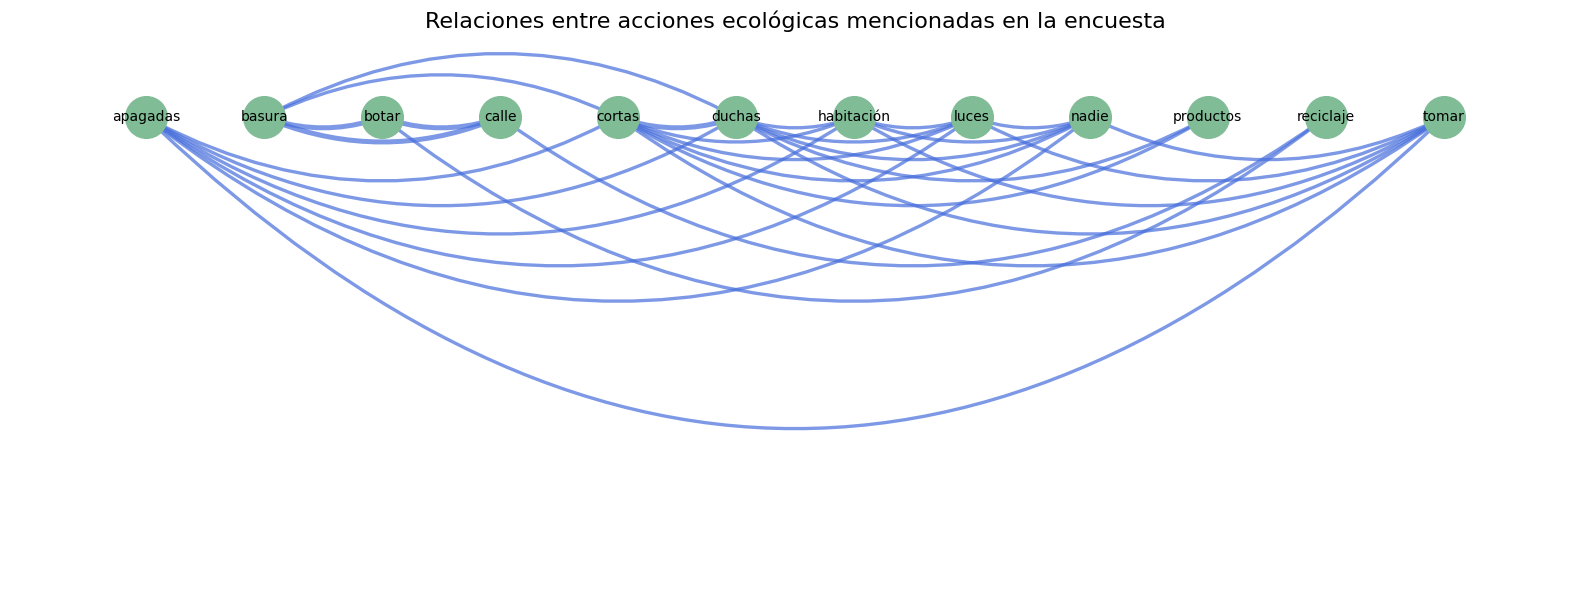

In [11]:
plt.figure(figsize=(16, 6))

# nodos
nx.draw_networkx_nodes(
    G,
    pos,
    node_size=900,
    node_color='#80bc96'
)

# etiquetas
nx.draw_networkx_labels(
    G,
    pos,
    font_size=10
)

# arcos
for i, (u, v, data) in enumerate(G.edges(data=True)):

    x1 = pos[u][0]
    x2 = pos[v][0]

    rad = 0.15 + abs(x2 - x1) * 0.03

    nx.draw_networkx_edges(
        G,
        pos,
        edgelist=[(u, v)],
        connectionstyle=f'arc3,rad={rad}',
        width=data['weight'] * 1.2,
        edge_color='#466edc',
        alpha=0.7,
        arrows=True,
        arrowstyle='-'
    )

plt.title(
    'Relaciones entre acciones ecológicas mencionadas en la encuesta',
    fontsize=16
)

plt.axis('off')
plt.tight_layout()
plt.show()